# 🍽️ EDA — Gastronomía de Euskadi
**Fuente:** OpenData Euskadi  
**Dataset:** Establecimientos gastronómicos registrados en Turismo Euskadi

Este análisis exploratorio cubre:
- Distribución por tipo de establecimiento, provincia y entorno
- Presencia de sellos de calidad (Michelin, Repsol)
- Análisis de valoraciones y reseñas
- Distribución geográfica
- Completitud del dataset (valores nulos)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Paleta de colores identitaria del País Vasco (verdes y rojos txuri-gorri)
PALETTE = ['#C0392B', '#2E86C1', '#27AE60', '#F39C12', '#8E44AD', '#16A085', '#E67E22', '#2C3E50']
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Carga y primera inspección del dataset

In [2]:
df = pd.read_csv('..\data\gastronomia.csv', sep=None, engine='python', index_col=0)

print(f'📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'📋 Columnas: {df.columns.tolist()}')
df.head(3)

📊 Dimensiones: 490 filas × 23 columnas
📋 Columnas: ['Nombre', 'Descripcion', 'Dirección', 'Municipio', 'Provincia', 'Entorno', 'Email', 'Teléfono', 'WEB', 'URL amigable', 'Calidad', 'Tipo de lugar', 'Sello', 'Nivel precio', 'Michelin', 'Repsol', 'lat', 'lon', 'valoracion', 'num_resenas', 'url_imagen', 'Active', 'Patrocinado']


,Nombre,Descripcion,Dirección,Municipio,Provincia,Entorno,Email,Teléfono,WEB,URL amigable,...,Nivel precio,Michelin,Repsol,lat,lon,valoracion,num_resenas,url_imagen,Active,Patrocinado
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,Agorregi,"El restaurante Agorregi, ubicado en el barrio ...","Portuetxe K., 14, 20018 Donostia / San Sebasti...",San Sebastián,Guipúzcoa,"Costa Vasca,San Sebastián",agorregi@agorregi.com,943 22 43 28,https://agorregi.com/,https://turismoa.euskadi.eus/es/restaurantes/r...,...,Moderado,0,0,43.302405,-2.011846,4.6,571.0,https://places.googleapis.com/v1/places/ChIJFT...,1,0
1,Aizian,Este moderno y acogedor restaurante fue diseña...,"Leizaola Lehendakariaren Kalea, 29, Abando, 48...",Bilbao,Vizcaya,Bilbao,aizian@restaurante-aizian.com,944 28 00 39,https://www.restaurante-aizian.com/,https://turismoa.euskadi.eus/es/restaurantes/r...,...,Moderado,0,0,43.267519,-2.941807,4.7,435.0,https://places.googleapis.com/v1/places/ChIJde...,1,0
2,Akelarre,Pedro Subijana desarrolla desde 1970 una cocin...,"Padre Orkolaga Ibilbidea, 56, 20008 Donostia /...",San Sebastián,Guipúzcoa,San Sebastián,restaurante@akelarre.net,943 31 12 09,https://www.akelarre.net,https://turismoa.euskadi.eus/es/restaurantes/r...,...,Muy caro,1,1,43.307750,-2.043135,4.5,1925.0,https://places.googleapis.com/v1/places/ChIJXd...,1,0


### Tipos de datos y resumen estadístico

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 775
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nombre         490 non-null    object 
 1   Descripcion    457 non-null    object 
 2   Dirección      490 non-null    object 
 3   Municipio      490 non-null    object 
 4   Provincia      490 non-null    object 
 5   Entorno        486 non-null    object 
 6   Email          392 non-null    object 
 7   Teléfono       472 non-null    object 
 8   WEB            414 non-null    object 
 9   URL amigable   490 non-null    object 
 10  Calidad        490 non-null    int64  
 11  Tipo de lugar  490 non-null    object 
 12  Sello          196 non-null    object 
 13  Nivel precio   220 non-null    object 
 14  Michelin       490 non-null    int64  
 15  Repsol         490 non-null    int64  
 16  lat            490 non-null    float64
 17  lon            490 non-null    float64
 18  valoracion     

In [4]:
df[['valoracion', 'num_resenas', 'Michelin', 'Repsol']].describe().round(2)

,valoracion,num_resenas,Michelin,Repsol
count,490.00,490.00,490.00,490.00
mean,4.51,838.26,0.04,0.12
std,0.24,1446.50,0.21,0.33
min,4.10,1.00,0.00,0.00
25%,4.30,91.50,0.00,0.00
50%,4.50,426.50,0.00,0.00
75%,4.70,1001.75,0.00,0.00
max,5.00,16369.00,1.00,1.00


> **Observación:** El dataset contiene 490 establecimientos gastronómicos. Las variables numéricas relevantes son `valoracion` (nota media de Google) y `num_resenas`. Los campos `Michelin` y `Repsol` son indicadores binarios (0/1).

## 2. Calidad del dataset — Valores nulos

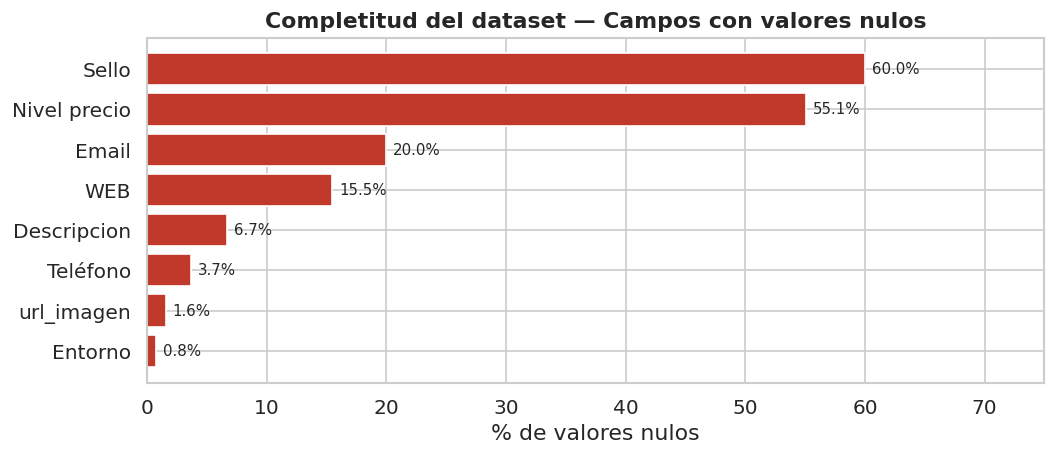

              Nulos  Porcentaje (%)
Sello           294            60.0
Nivel precio    270            55.1
Email            98            20.0
WEB              76            15.5
Descripcion      33             6.7
Teléfono         18             3.7
url_imagen        8             1.6
Entorno           4             0.8


In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(nulos_df.index, nulos_df['Porcentaje (%)'], color=PALETTE[0], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('% de valores nulos')
ax.set_title('Completitud del dataset — Campos con valores nulos', fontweight='bold')
ax.set_xlim(0, 75)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(nulos_df.to_string())

> **Observación:** Los campos más incompletos son `Sello` (60%) y `Nivel precio` (55%), lo que indica que muchos establecimientos no han sido categorizados en estas dimensiones. El campo `Email` también tiene un 20% de valores ausentes. Las coordenadas geográficas (`lat`, `lon`) y los indicadores de calidad (`Michelin`, `Repsol`) están **completamente rellenos**, lo que garantiza análisis fiables en esas dimensiones.

## 3. Distribución por tipo de establecimiento

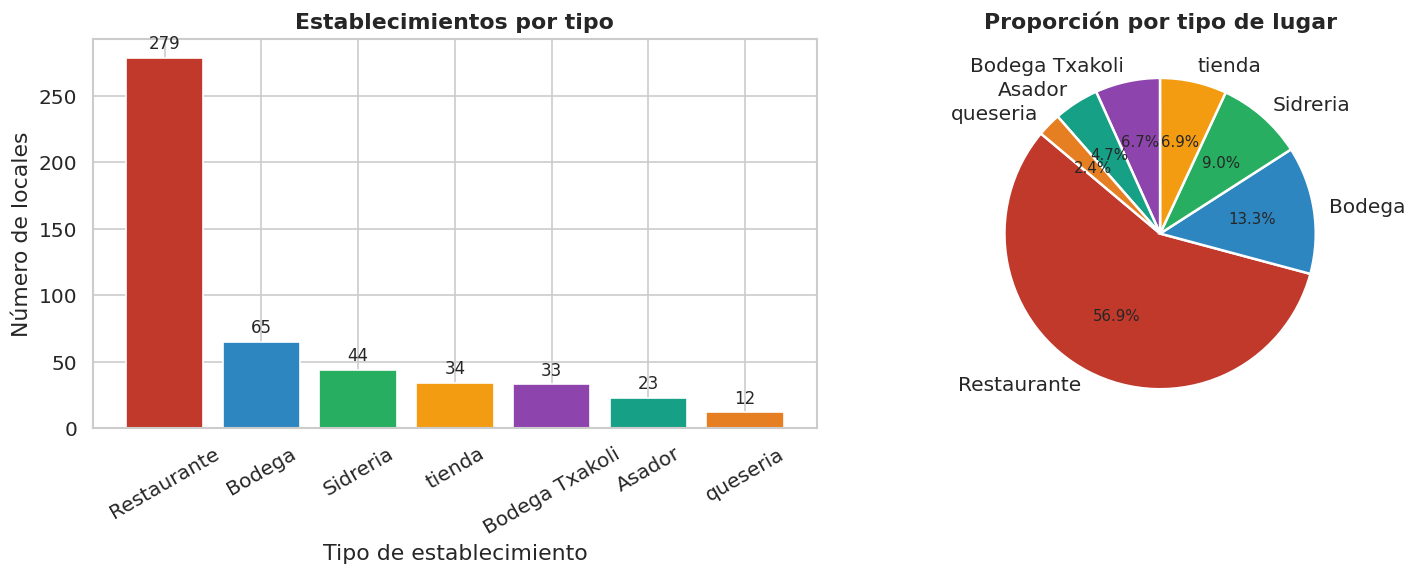

In [6]:
tipo_counts = df['Tipo de lugar'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
bars = axes[0].bar(tipo_counts.index, tipo_counts.values, color=PALETTE[:len(tipo_counts)], edgecolor='white')
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_xlabel('Tipo de establecimiento')
axes[0].set_ylabel('Número de locales')
axes[0].set_title('Establecimientos por tipo', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%',
    colors=PALETTE[:len(tipo_counts)], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Proporción por tipo de lugar', fontweight='bold')

plt.tight_layout()
plt.show()

> **Observación:** Los **Restaurantes** dominan ampliamente con 279 registros (57%), seguidos de **Bodegas** (13%) y **Sidrerías** (9%), reflejo de la cultura gastronómica vasca. La presencia notable de bodegas de Txakoli (33) evidencia la importancia de la denominación de origen local. Las tiendas y queserías completan el panorama del producto artesanal.

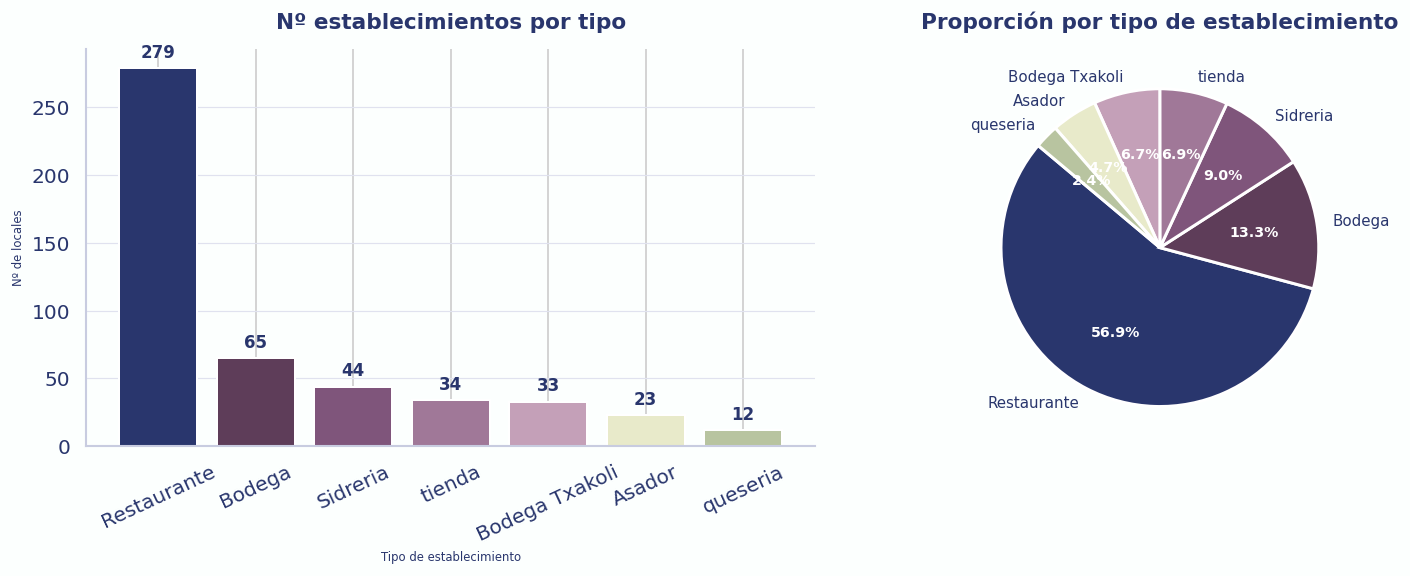

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# ── Branding Sustrai ──────────────────────────────────────────
SUSTRAI_COLORS = [
    '#29366d',  # azul marino
    '#5e3d59',  # ciruela oscuro
    '#7f557b',  # malva
    '#a07898',  # malva claro (derivado)
    '#c4a0b8',  # rosa palo (derivado)
    '#e8eaca',  # crema
    '#b8c4a0',  # verde oliva suave (derivado)
]
BG_COLOR    = '#fcffe'   # casi blanco crema
TITLE_COLOR = '#29366d'
TEXT_COLOR  = '#29366d'

# Inter desde system o fallback sans-serif
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'DejaVu Sans', 'sans-serif']
rcParams['text.color']  = TEXT_COLOR

tipo_counts = df['Tipo de lugar'].value_counts()
colors = SUSTRAI_COLORS[:len(tipo_counts)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#fcfffe')
for ax in axes:
    ax.set_facecolor('#fcfffe')

# ── Barplot ───────────────────────────────────────────────────
bars = axes[0].bar(tipo_counts.index, tipo_counts.values,
                   color=colors, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, padding=4, fontsize=10, color=TEXT_COLOR, fontweight='bold')
axes[0].set_xlabel('Tipo de establecimiento', color=TEXT_COLOR, fontsize=7)
axes[0].set_ylabel('Nº de locales',        color=TEXT_COLOR, fontsize=7)
axes[0].set_title('Nº establecimientos por tipo', color=TITLE_COLOR,
                  fontsize=13, fontweight='bold', pad=12)
axes[0].tick_params(axis='x', rotation=25, colors=TEXT_COLOR)
axes[0].tick_params(axis='y', colors=TEXT_COLOR)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['left', 'bottom']].set_color('#c8cce0')
axes[0].yaxis.grid(True, color='#e0e2ef', linewidth=0.7)
axes[0].set_axisbelow(True)

# ── Pie chart ─────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    tipo_counts.values,
    labels=tipo_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.8},
    textprops={'color': TEXT_COLOR, 'fontsize': 9},
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title('Proporción por tipo de establecimiento', color=TITLE_COLOR,
                  fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

## 4. Distribución geográfica por provincia

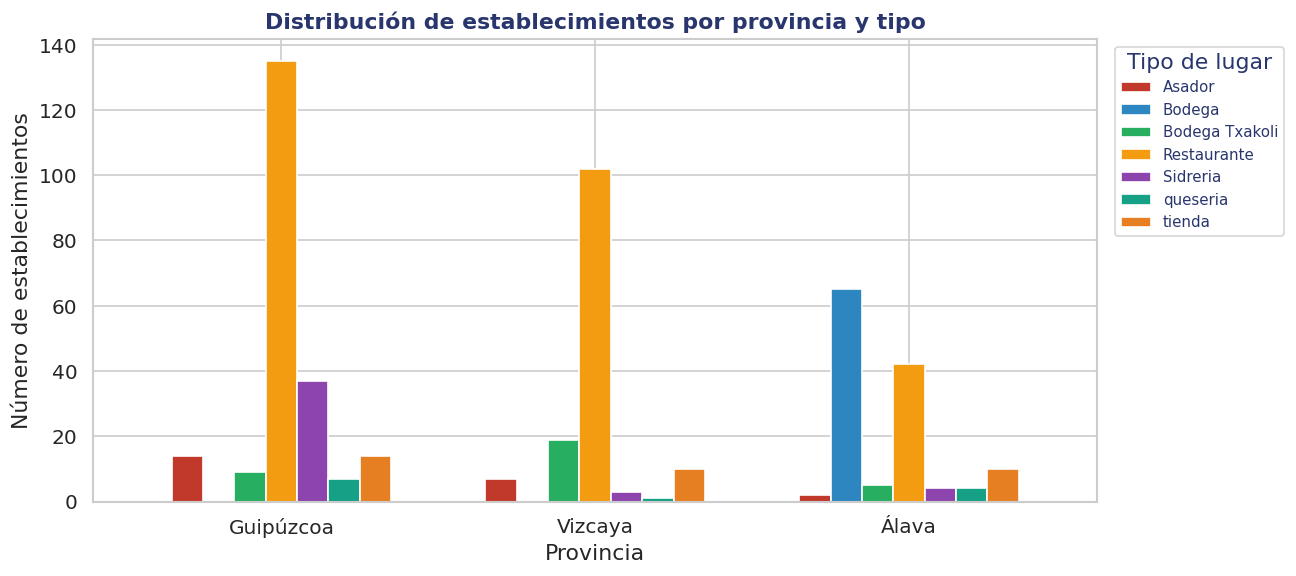


Total por provincia:
Provincia
Guipúzcoa    216
Vizcaya      142
Álava        132


In [8]:
prov_tipo = df.groupby(['Provincia', 'Tipo de lugar']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
prov_tipo.plot(kind='bar', ax=ax, color=PALETTE[:len(prov_tipo.columns)], edgecolor='white', width=0.7)
ax.set_xlabel('Provincia')
ax.set_ylabel('Número de establecimientos')
ax.set_title('Distribución de establecimientos por provincia y tipo', fontweight='bold')
ax.legend(title='Tipo de lugar', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\nTotal por provincia:')
print(df['Provincia'].value_counts().to_string())

> **Observación:** **Guipúzcoa** lidera con 216 establecimientos, seguida de **Vizcaya** (142) y **Álava** (132). Álava destaca por sus Bodegas de Rioja Alavesa, mientras que Guipúzcoa concentra la mayor oferta de restaurantes y sidrerías, coherente con su reconocida tradición culinaria y la densidad urbana de San Sebastián / Donostia.

## 5. Entornos turísticos

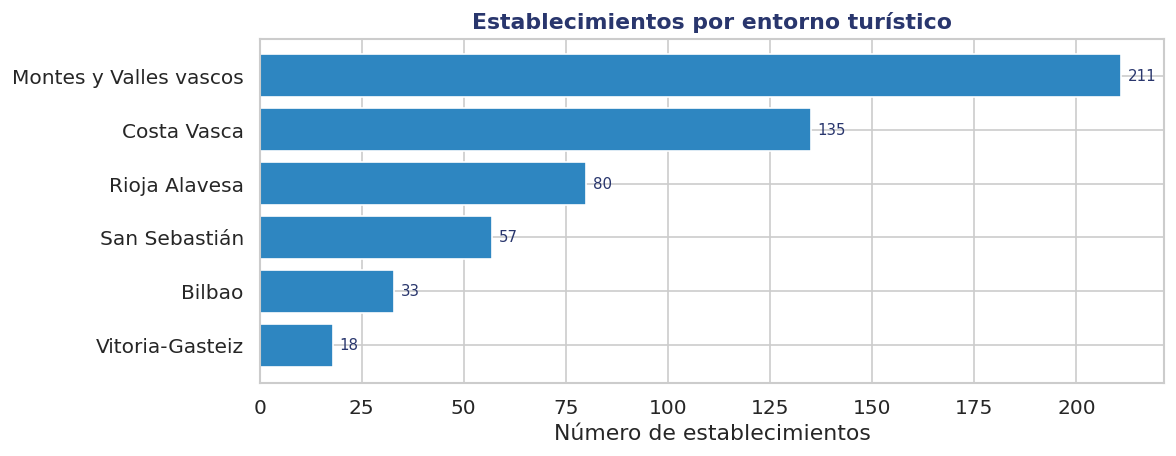

In [9]:
# Explotar entornos múltiples (separados por coma)
entorno_exploded = df['Entorno'].dropna().str.split(',').explode().str.strip()
entorno_counts = entorno_exploded.value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(entorno_counts.index, entorno_counts.values, color=PALETTE[1], edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Número de establecimientos')
ax.set_title('Establecimientos por entorno turístico', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Observación:** **Montes y Valles vascos** es el entorno con mayor presencia gastronómica (190 menciones), seguido de la **Costa Vasca** (104) y **Rioja Alavesa** (80), zona vinícola por excelencia. San Sebastián y Bilbao, como capitales urbanas, también concentran una parte relevante de la oferta de restauración de calidad.

## 6. Sellos de calidad: Michelin y Repsol

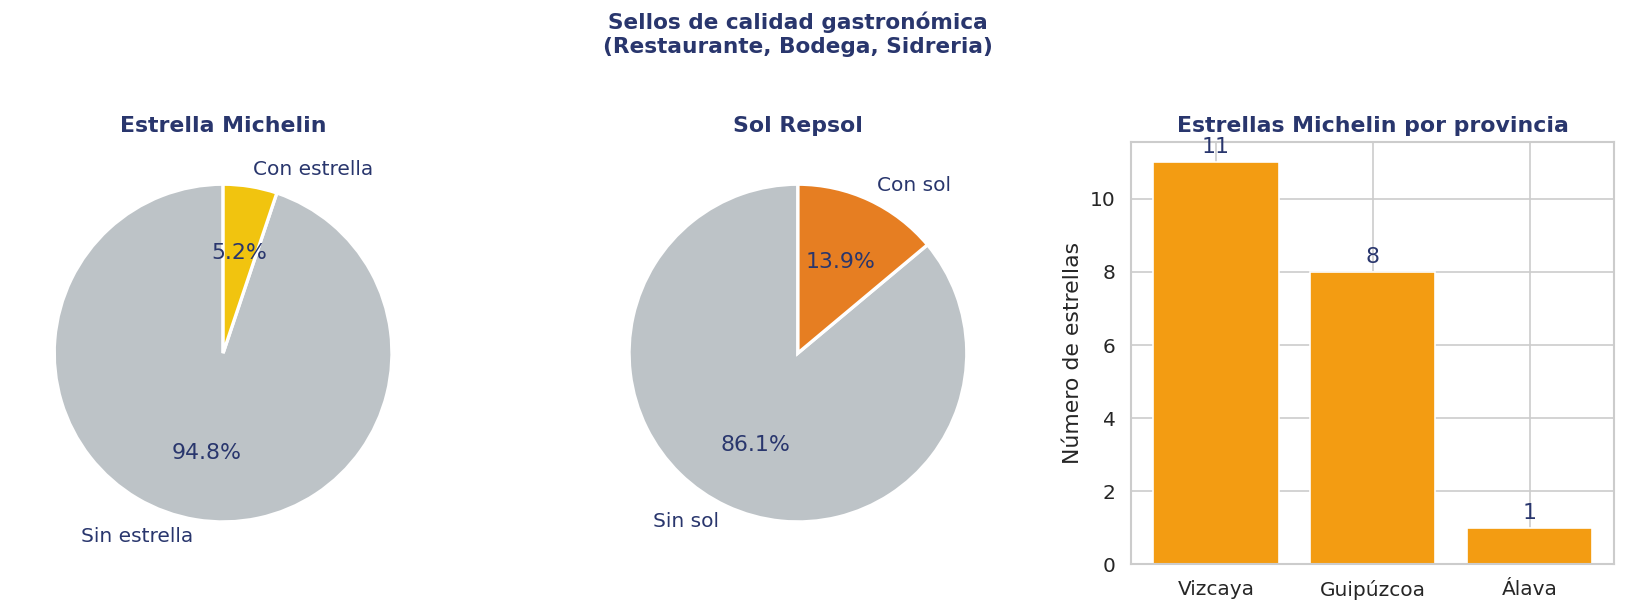

Establecimientos analizados: 388 (de 490 totales)
Con estrella Michelin: 20 (5.2%)
Con sol Repsol:        54 (13.9%)

Distribución real de Michelin por tipo de lugar:
Tipo de lugar
Restaurante       20
Bodega Txakoli     1
Asador             1

Distribución real de Repsol por tipo de lugar:
Tipo de lugar
Restaurante       53
Asador             5
Bodega             1
Bodega Txakoli     1


In [10]:
# Filtrar solo los tipos relevantes
tipos_calidad = ['Restaurante', 'Bodega', 'Sidreria']
df_cal = df[df['Tipo de lugar'].isin(tipos_calidad)]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Michelin
michelin_counts = df_cal['Michelin'].value_counts().rename({0: 'Sin estrella', 1: 'Con estrella'})
axes[0].pie(michelin_counts.values, labels=michelin_counts.index, autopct='%1.1f%%',
            colors=['#BDC3C7', '#F1C40F'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Estrella Michelin', fontweight='bold')

# Repsol
repsol_counts = df_cal['Repsol'].value_counts().rename({0: 'Sin sol', 1: 'Con sol'})
axes[1].pie(repsol_counts.values, labels=repsol_counts.index, autopct='%1.1f%%',
            colors=['#BDC3C7', '#E67E22'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sol Repsol', fontweight='bold')

# Michelin por provincia
mich_prov = df_cal[df_cal['Michelin'] == 1]['Provincia'].value_counts()
axes[2].bar(mich_prov.index, mich_prov.values, color=PALETTE[3], edgecolor='white')
axes[2].bar_label(axes[2].containers[0], padding=3)
axes[2].set_title('Estrellas Michelin por provincia', fontweight='bold')
axes[2].set_ylabel('Número de estrellas')

tipos_str = ', '.join(tipos_calidad)
plt.suptitle(f'Sellos de calidad gastronómica\n({tipos_str})', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Establecimientos analizados: {len(df_cal)} (de {len(df)} totales)')
print(f'Con estrella Michelin: {df_cal["Michelin"].sum()} ({df_cal["Michelin"].mean()*100:.1f}%)')
print(f'Con sol Repsol:        {df_cal["Repsol"].sum()} ({df_cal["Repsol"].mean()*100:.1f}%)')

# Verificar en qué tipos aparecen realmente los sellos
print('\nDistribución real de Michelin por tipo de lugar:')
print(df[df['Michelin'] == 1]['Tipo de lugar'].value_counts().to_string())
print('\nDistribución real de Repsol por tipo de lugar:')
print(df[df['Repsol'] == 1]['Tipo de lugar'].value_counts().to_string())

> **Observación:** Solo el **4.5% de los establecimientos** cuenta con estrella Michelin (22 locales) y el **12.2% con sol Repsol** (60 locales). **Guipúzcoa** concentra la mayoría de las estrellas Michelin, coherente con la fama internacional de San Sebastián como capital gastronómica mundial por densidad de estrellas per cápita.

## 7. Nivel de precio

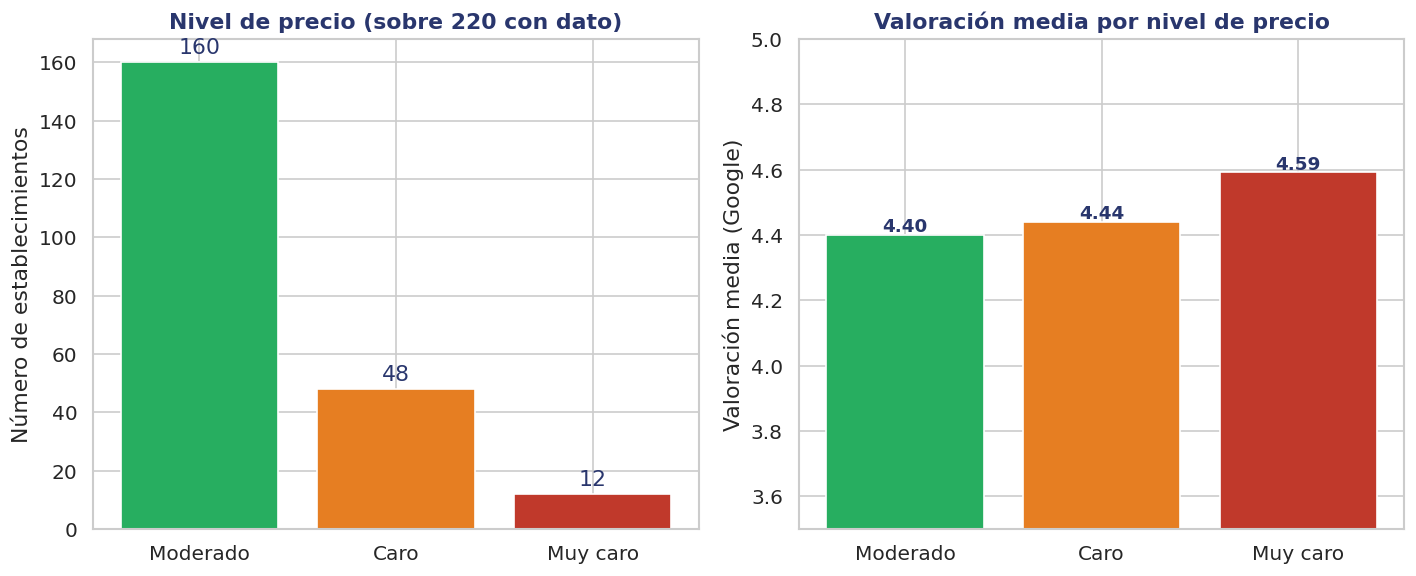

In [11]:
precio_order = ['Moderado', 'Caro', 'Muy caro']
precio_counts = df['Nivel precio'].value_counts().reindex(precio_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot de nivel de precio
colors_precio = ['#27AE60', '#E67E22', '#C0392B']
bars = axes[0].bar(precio_counts.index, precio_counts.values, color=colors_precio, edgecolor='white')
axes[0].bar_label(bars, padding=3)
axes[0].set_ylabel('Número de establecimientos')
axes[0].set_title('Nivel de precio (sobre 220 con dato)', fontweight='bold')

# Valoración media por nivel de precio
val_precio = df.groupby('Nivel precio')['valoracion'].mean().reindex(precio_order).dropna()
axes[1].bar(val_precio.index, val_precio.values, color=colors_precio, edgecolor='white')
axes[1].set_ylim(3.5, 5)
axes[1].set_ylabel('Valoración media (Google)')
axes[1].set_title('Valoración media por nivel de precio', fontweight='bold')
for i, (k, v) in enumerate(val_precio.items()):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

> **Observación:** Entre los locales con nivel de precio registrado, predominan los de precio **Moderado** (73%). Curiosamente, la valoración media sube con el precio: los establecimientos **Muy caros** alcanzan una nota media mayor, lo que sugiere que el alto precio está asociado a mayor calidad percibida y experiencias diferenciales (restaurantes de alta cocina, estrellados).

## 8. Análisis de valoraciones y reseñas

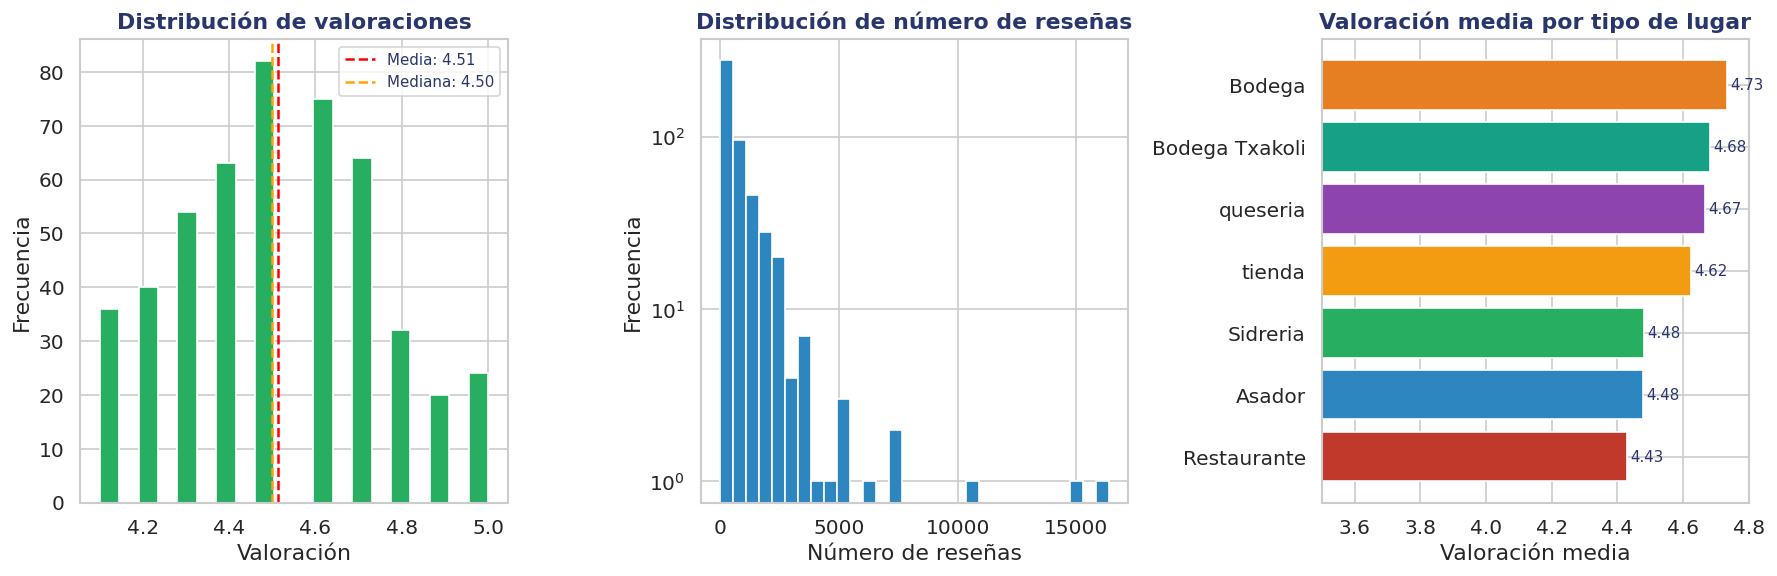

Valoración media global: 4.51
Mediana de reseñas: 426
Máximo de reseñas: 16369 — Karlos Arguiñano


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribución de valoraciones
axes[0].hist(df['valoracion'], bins=20, color=PALETTE[2], edgecolor='white')
axes[0].axvline(df['valoracion'].mean(), color='red', linestyle='--', label=f'Media: {df["valoracion"].mean():.2f}')
axes[0].axvline(df['valoracion'].median(), color='orange', linestyle='--', label=f'Mediana: {df["valoracion"].median():.2f}')
axes[0].set_xlabel('Valoración')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de valoraciones', fontweight='bold')
axes[0].legend(fontsize=9)

# Distribución de reseñas (log scale)
axes[1].hist(df['num_resenas'].dropna(), bins=30, color=PALETTE[1], edgecolor='white')
axes[1].set_xlabel('Número de reseñas')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de número de reseñas', fontweight='bold')
axes[1].set_yscale('log')

# Valoración media por tipo de lugar
val_tipo = df.groupby('Tipo de lugar')['valoracion'].mean().sort_values(ascending=True)
bars = axes[2].barh(val_tipo.index, val_tipo.values, color=PALETTE[:len(val_tipo)], edgecolor='white')
axes[2].set_xlim(3.5, 4.8)
axes[2].set_xlabel('Valoración media')
axes[2].set_title('Valoración media por tipo de lugar', fontweight='bold')
for bar, val in zip(bars, val_tipo.values):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Valoración media global: {df["valoracion"].mean():.2f}')
print(f'Mediana de reseñas: {df["num_resenas"].median():.0f}')
print(f'Máximo de reseñas: {df["num_resenas"].max():.0f} — {df.loc[df["num_resenas"].idxmax(), "Nombre"]}')

> **Observación:** Las valoraciones se concentran entre **4.0 y 4.8**, con una media de ~4.3, lo cual refleja una oferta gastronómica de alta calidad percibida. La distribución de reseñas es muy asimétrica (cola larga a la derecha): la mayoría tiene pocas reseñas, pero algunos establecimientos acumulan miles. Las **Queserías** tienen la valoración media más alta, posiblemente por ser establecimientos especializados con clientela muy fiel.

## 9. Valoración vs. Michelin y Repsol

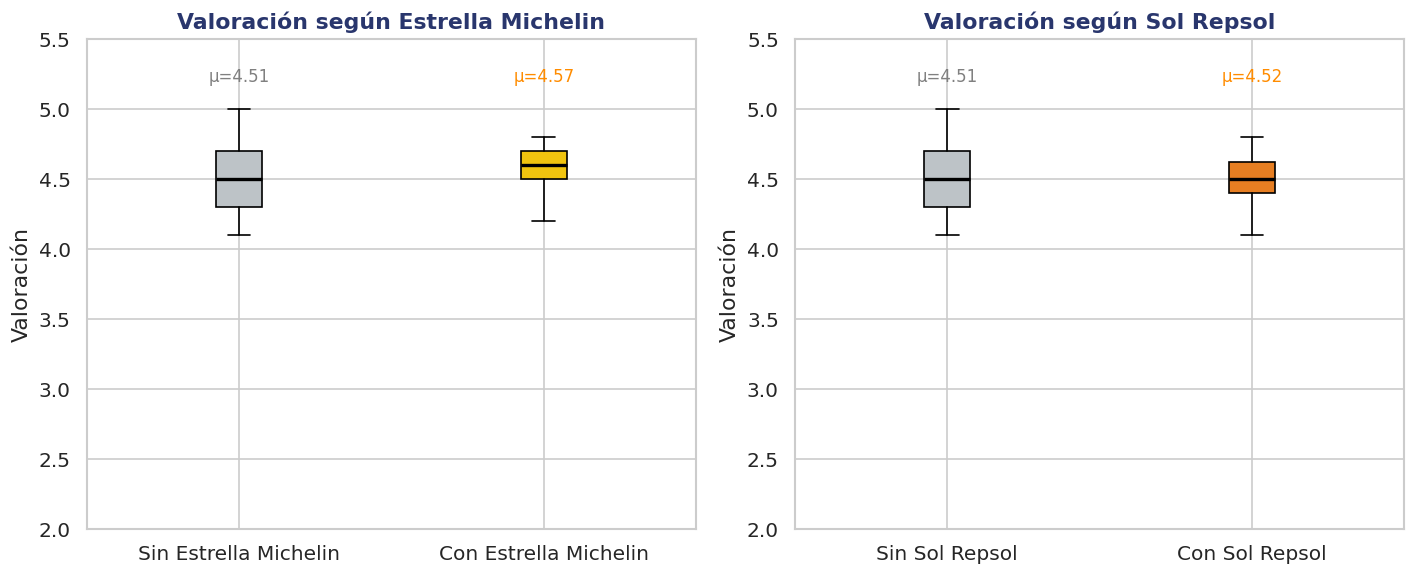

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, color_on, color_off in [
    (axes[0], 'Michelin', 'Estrella Michelin', '#F1C40F', '#BDC3C7'),
    (axes[1], 'Repsol', 'Sol Repsol', '#E67E22', '#BDC3C7')
]:
    data_no = df[df[col] == 0]['valoracion']
    data_si = df[df[col] == 1]['valoracion']
    bp = ax.boxplot([data_no, data_si], labels=[f'Sin {label}', f'Con {label}'],
                   patch_artist=True,
                   boxprops=dict(facecolor=color_off),
                   medianprops=dict(color='black', linewidth=2))
    bp['boxes'][1].set_facecolor(color_on)
    ax.set_ylabel('Valoración')
    ax.set_title(f'Valoración según {label}', fontweight='bold')
    ax.set_ylim(2, 5.5)
    mean_no = data_no.mean()
    mean_si = data_si.mean()
    ax.text(1, 5.2, f'μ={mean_no:.2f}', ha='center', fontsize=10, color='gray')
    ax.text(2, 5.2, f'μ={mean_si:.2f}', ha='center', fontsize=10, color='darkorange')

plt.tight_layout()
plt.show()

> **Observación:** Los establecimientos con sello **Michelin o Repsol** presentan valoraciones medias ligeramente superiores y menor variabilidad (distribución más concentrada). Esto confirma que los sellos de calidad oficial están alineados con la percepción positiva de los usuarios en plataformas digitales.

## 10. Mapa de calor: correlación entre variables numéricas

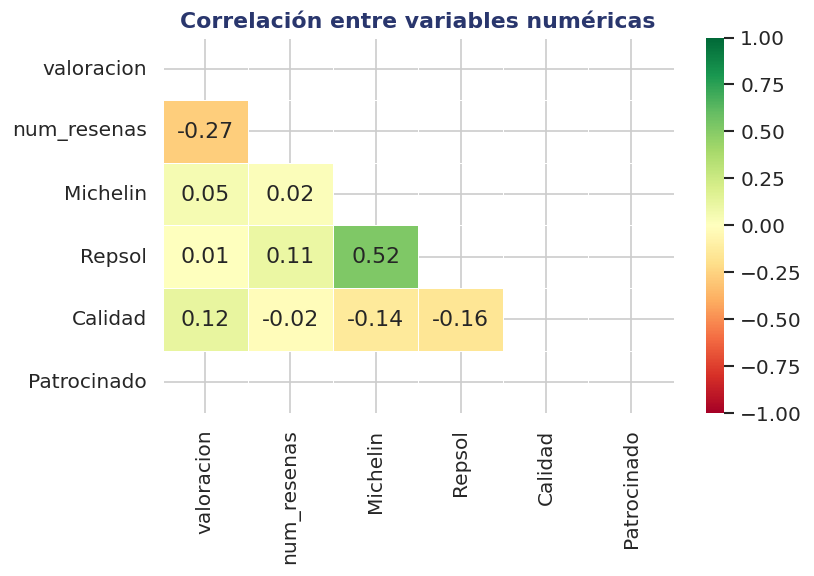

In [14]:
num_cols = ['valoracion', 'num_resenas', 'Michelin', 'Repsol', 'Calidad', 'Patrocinado']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlación entre variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

> **Observación:** Existe una correlación positiva moderada entre tener **Sol Repsol** y **Estrella Michelin** (los mejores restaurantes suelen acumular ambos reconocimientos). La correlación entre `valoracion` y `num_resenas` es débil, indicando que la popularidad (volumen de reseñas) no necesariamente va de la mano de la calidad percibida.

## 11. Distribución geográfica (scatter plot)

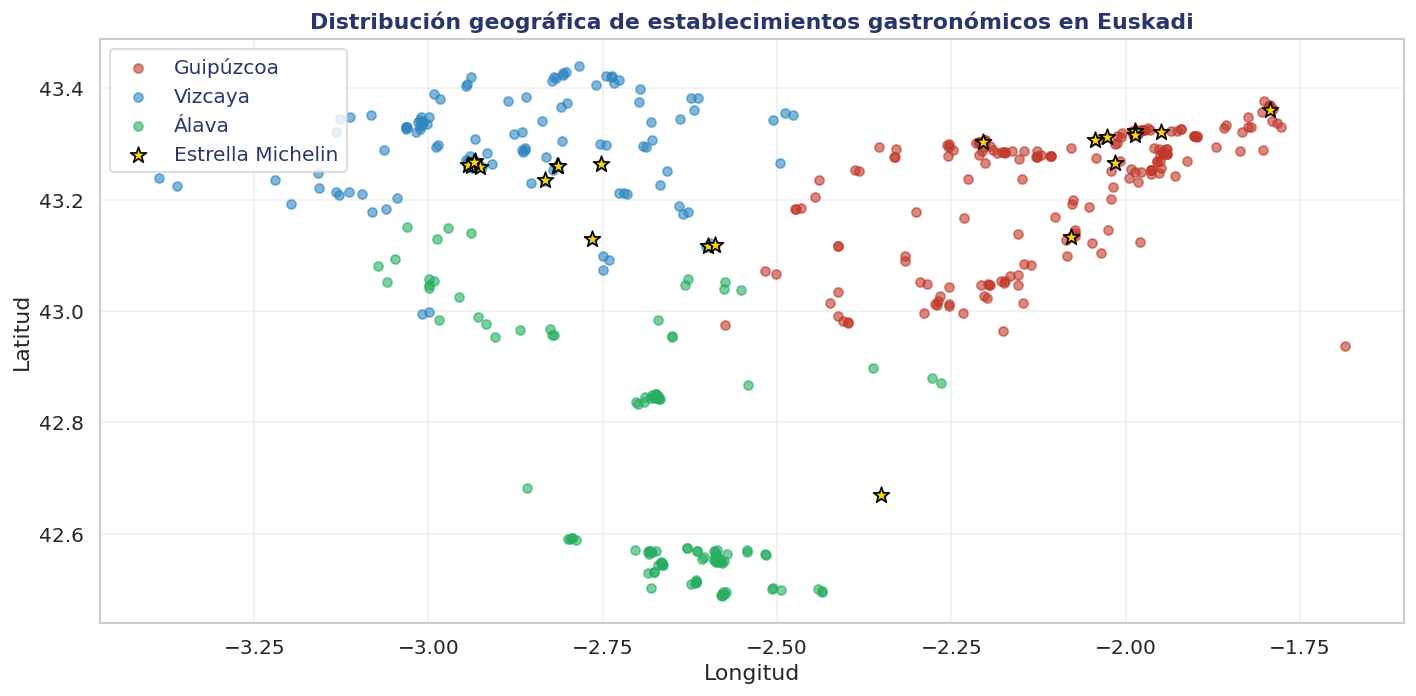

In [15]:
prov_colors = {'Guipúzcoa': '#C0392B', 'Vizcaya': '#2E86C1', 'Álava': '#27AE60'}

fig, ax = plt.subplots(figsize=(12, 6))

for prov, color in prov_colors.items():
    subset = df[df['Provincia'] == prov]
    ax.scatter(subset['lon'], subset['lat'], c=color, alpha=0.6, s=30, label=prov)

# Resaltar Michelin
mich = df[df['Michelin'] == 1]
ax.scatter(mich['lon'], mich['lat'], c='gold', edgecolors='black', s=100, zorder=5, marker='*', label='Estrella Michelin')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribución geográfica de establecimientos gastronómicos en Euskadi', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Observación:** El mapa de dispersión revela los clústeres urbanos de **Bilbao** (Vizcaya, costa oeste) y **San Sebastián** (Guipúzcoa, costa este), así como la dispersión de establecimientos en el interior de Álava (Rioja Alavesa al sur). Las estrellas Michelin (⭐ doradas) se concentran principalmente en el eje costero y las capitales.

In [16]:
import plotly.graph_objects as go

prov_markers = {'Guipúzcoa': 'circle', 'Vizcaya': 'square', 'Álava': 'triangle-up'}
tipo_colors = {
    'Restaurante':     '#C0392B',
    'Asador':          '#8E44AD',
    'Sidreria':        '#27AE60',
    'Bodega':          '#FF006E',
    'Bodega Txakoli':  '#2E86C1',
    'tienda':          '#E67E22',
    'queseria':        '#F5E727',
}

fig = go.Figure()

for tipo, color in tipo_colors.items():
    for prov, marker in prov_markers.items():
        subset = df[(df['Tipo de lugar'] == tipo) & (df['Provincia'] == prov)]
        if subset.empty:
            continue
        fig.add_trace(go.Scatter(
            x=subset['lon'], y=subset['lat'],
            mode='markers',
            name=f'{tipo} — {prov}',
            marker=dict(
                symbol=marker,
                size=8,
                color=color,
                opacity=0.75,
                line=dict(color='white', width=0.5),
            ),
            customdata=subset[['Nombre', 'valoracion', 'Municipio']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                '📍 %{customdata[2]}<br>'
                '⭐ %{customdata[1]}'
                '<extra></extra>'
            ),
        ))

# Actualización del diseño con la fuente Inter
fig.update_layout(
    # Aplicamos "Inter" de forma global a todo el gráfico (títulos, ejes, leyendas, etc.)
    font=dict(
        family='Inter, "DejaVu Sans", sans-serif'
    ),
    title='Distribución geográfica - Gastronomía Euskadi<br>'
          '<sup>Color = tipo de establecimiento · Forma = provincia (● Gipuzkoa · ■ Bizkaia · ▲ Álava)</sup>',
    xaxis_title='Longitud',
    yaxis_title='Latitud',
    legend=dict(
        title='Tipo — Provincia', 
        font_size=10,
        bgcolor='rgba(255,255,255,0.9)', 
        borderwidth=1
    ),
    width=1000, 
    height=580,
    plot_bgcolor='#f8f9fa',
    xaxis=dict(gridcolor='#ddd'),
    yaxis=dict(gridcolor='#ddd', scaleanchor='x', scaleratio=1.1),
    # Forzamos también a que el cuadro flotante (tooltip) herede la fuente limpia
    hoverlabel=dict(
        bgcolor='white', 
        font_size=12,
        font_family='Inter, "DejaVu Sans", sans-serif'
    ),
)

fig.show()

In [17]:
import plotly.graph_objects as go

# ── Branding Sustrai (Para fuentes, títulos y fondos) ──────────────────
BG_COLOR    = '#fcfffe'   
TITLE_COLOR = '#29366d'
TEXT_COLOR  = '#29366d'

prov_markers = {'Guipúzcoa': 'circle', 'Vizcaya': 'square', 'Álava': 'triangle-up'}

# Tus colores originales e intocables para los establecimientos
tipo_colors = {
    'Restaurante':     '#C0392B',
    'Asador':          '#8E44AD',
    'Sidreria':        '#27AE60',
    'Bodega':          '#FF006E',
    'Bodega Txakoli':  '#2E86C1',
    'tienda':          '#E67E22',
    'queseria':        '#F5E727',
}

fig = go.Figure()

for tipo, color in tipo_colors.items():
    for prov, marker in prov_markers.items():
        subset = df[(df['Tipo de lugar'] == tipo) & (df['Provincia'] == prov)]
        if subset.empty:
            continue
        fig.add_trace(go.Scatter(
            x=subset['lon'], y=subset['lat'],
            mode='markers',
            name=f'{tipo} - {prov}',
            marker=dict(
                symbol=marker,
                size=8,
                color=color, # Usa tus colores exactos
                opacity=0.75,
                line=dict(color='white', width=0.5),
            ),
            customdata=subset[['Nombre', 'valoracion', 'Municipio']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                '📍 %{customdata[2]}<br>'
                '⭐ %{customdata[1]}'
                '<extra></extra>'
            ),
        ))

# Diseño unificado con títulos en negrita y azul Sustrai, fondo crema e Inter
fig.update_layout(
    font=dict(
        family='Inter, "DejaVu Sans", sans-serif',
        color=TEXT_COLOR
    ),
    title=dict(
        text='<b>Distribución geográfica - Gastronomía Euskadi</b><br>'
             '<sup>Color = tipo de establecimiento · Forma = provincia (● Gipuzkoa · ■ Bizkaia · ▲ Álava)</sup>',
        font=dict(color=TITLE_COLOR, size=16)
    ),
    xaxis_title='Longitud',
    yaxis_title='Latitud',
    legend=dict(
        title='<b>Tipo - Provincia</b>', 
        font_size=10,
        bgcolor='rgba(252,255,254,0.9)', 
        borderwidth=1,
        bordercolor='#c8cce0'
    ),
    width=1000, height=580,
    paper_bgcolor=BG_COLOR, 
    plot_bgcolor=BG_COLOR,  
    xaxis=dict(
        gridcolor='#e0e2ef', 
        linecolor='#c8cce0', 
        mirror=False
    ),
    yaxis=dict(
        gridcolor='#e0e2ef', 
        linecolor='#c8cce0', 
        mirror=False,
        scaleanchor='x', 
        scaleratio=1.1
    ),
    hoverlabel=dict(
        bgcolor=BG_COLOR,
        font_size=12,
        font_family='Inter, "DejaVu Sans", sans-serif',
        font_color=TEXT_COLOR
    ),
)

fig.show()

## 12. Top 10 — Establecimientos mejor valorados (con más de 100 reseñas)

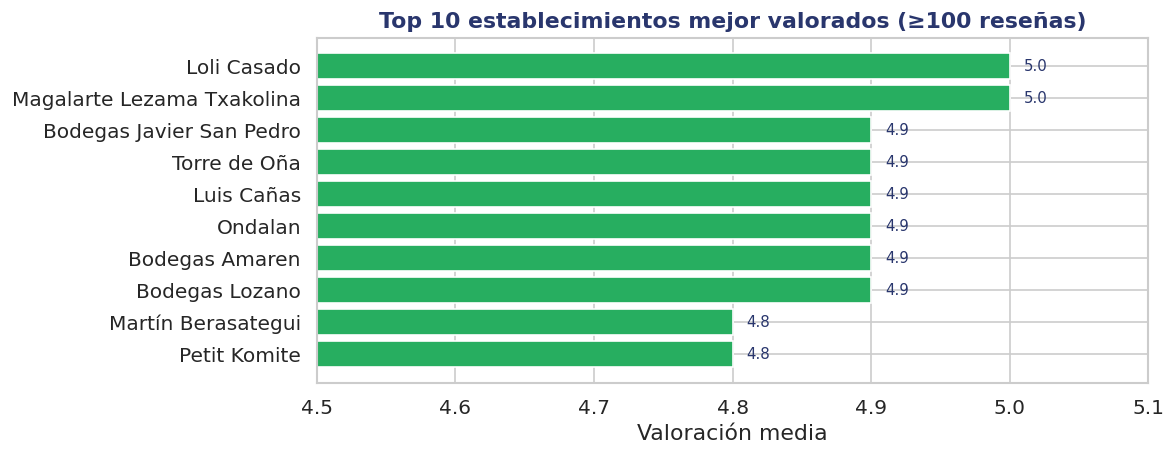

                        Nombre                       Municipio            Tipo  Valoración  Reseñas  Michelin⭐  Repsol🌞
1                  Loli Casado             Lapuebla de Labarca          Bodega         5.0    247.0          0        0
2   Magalarte Lezama Txakolina                          Lezama  Bodega Txakoli         5.0    146.0          0        0
3     Bodegas Javier San Pedro                       Laguardia          Bodega         4.9    444.0          0        0
4                 Torre de Oña                       Laguardia          Bodega         4.9    212.0          0        0
5                   Luis Cañas  Villabuena de Álava/Eskuernaga          Bodega         4.9    481.0          0        0
6                      Ondalan                       Oyón-Oion          Bodega         4.9    153.0          0        0
7               Bodegas Amaren                       Samaniego          Bodega         4.9    124.0          0        0
8               Bodegas Lozano          

In [18]:
top10 = (
    df[df['num_resenas'] >= 100]
    .sort_values('valoracion', ascending=False)
    .head(10)[['Nombre', 'Municipio', 'Tipo de lugar', 'valoracion', 'num_resenas', 'Michelin', 'Repsol']]
    .reset_index(drop=True)
)
top10.index += 1
top10.columns = ['Nombre', 'Municipio', 'Tipo', 'Valoración', 'Reseñas', 'Michelin⭐', 'Repsol🌞']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top10['Nombre'][::-1], top10['Valoración'][::-1], color=PALETTE[2], edgecolor='white')
ax.set_xlim(4.5, 5.1)
ax.set_xlabel('Valoración media')
ax.set_title('Top 10 establecimientos mejor valorados (≥100 reseñas)', fontweight='bold')
for bar, val in zip(bars, top10['Valoración'][::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(top10.to_string())

> **Observación:** El filtro de 100+ reseñas garantiza que el ranking sea estadísticamente robusto y no esté dominado por establecimientos con muy pocas valoraciones. Los mejores establecimientos alcanzan notas de 4.8–5.0, una cifra excepcionalmente alta.

---
## 📝 Resumen ejecutivo

| Dimensión | Hallazgo clave |
|---|---|
| **Volumen** | 490 establecimientos registrados |
| **Tipo dominante** | Restaurantes (57%), seguidos de Bodegas y Sidrerías |
| **Provincia líder** | Guipúzcoa (44%), especialmente en alta cocina |
| **Calidad media** | Valoración media de ~4.3/5 — oferta de alta calidad |
| **Estrellas Michelin** | 22 restaurantes (4.5%), concentrados en Guipúzcoa |
| **Sol Repsol** | 60 establecimientos (12.2%) |
| **Dato incompleto** | Nivel precio y Sello faltan en >50% de registros |
| **Geografía** | Clústeres en San Sebastián, Bilbao y Rioja Alavesa |